<a href="https://colab.research.google.com/github/ibtihalalf/Sdaia-Bootcamp/blob/main/Projects/P2_Student_Exam_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Exam Performance Analysis

## Objective
The goal of this project is to explore the factors associated with student exam performance and identify which variables appear to have the strongest relationship with `Exam_Score`.

This analysis will:
- inspect the dataset structure and quality
- explore relationships between features and exam performance
- generate hypotheses from the exploration
- verify those hypotheses using statistical tests
- conclude with key insights and recommendations

Load libraries

In [1]:
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import numpy as np # linear algebra

# for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical testing
from scipy.stats import pearsonr, ttest_ind, f_oneway, chi2_contingency
from statsmodels.stats.multicomp import pairwise_tukeyhsd

import kagglehub
import os


Load dataset

In [2]:

# ================================
#  Download & Load Dataset
# ================================
DATASET = "grandmaster07/student-exam-performance-dataset-analysis"
FILE_NAME = "StudentPerformanceFactors.csv"

# Download dataset
data_path = kagglehub.dataset_download(DATASET)

# Load CSV
file_path = os.path.join(data_path, FILE_NAME)
df = pd.read_csv(file_path)

Using Colab cache for faster access to the 'student-exam-performance-dataset-analysis' dataset.


In [3]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [5]:
df.isna().sum().sort_values(ascending=False)

,0
Parental_Education_Level,90
Teacher_Quality,78
Distance_from_Home,67
Hours_Studied,0
Access_to_Resources,0
Parental_Involvement,0
Attendance,0
Extracurricular_Activities,0
Motivation_Level,0
Internet_Access,0


In [6]:
df.duplicated().sum()

np.int64(0)

 Data Understanding Summary:
 - the dataset contains 6607 rows and 20 columns
 - there are both numerical and categorical features
 - some missing values exist in: Teacher_Quality - Parental_Education_Level - Didtance_form_Home
 - Overall, the data is mostly clean

In [7]:
df["Exam_Score"].mean()

np.float64(67.23565914938702)

The Average exam scores is approximately 67

## Initial assumptions
Before exploring the dataset in depth, the following assumptions can be made:

- Students with more study hours are likely to have higher exam scores.
- Higher attendance may be associated with better academic performance.
- Sleep duration may have a positive relationship with exam scores up to a reasonable level.
- Students receiving tutoring sessions may perform better than those who do not.
- Motivation and parental involvement may positively influence performance.
- School type and access-related factors may also contribute to exam score differences.

There is 90 missing values in Parental Education Level , 78 in Teatcher Quality and 67 Distance from home features.

Separate numerical and categorical columns

In [9]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']
Categorical columns: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


# Univariate exploration

Numerical distributions

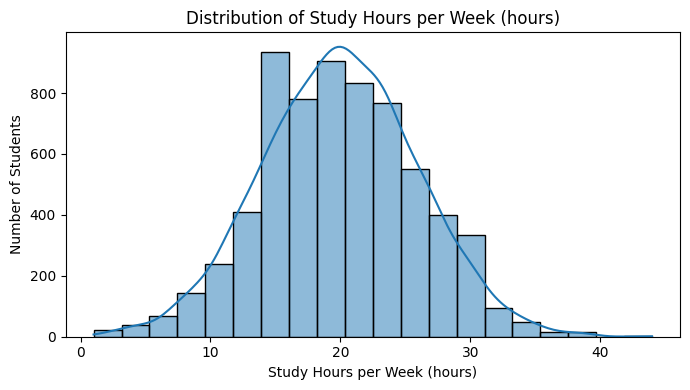

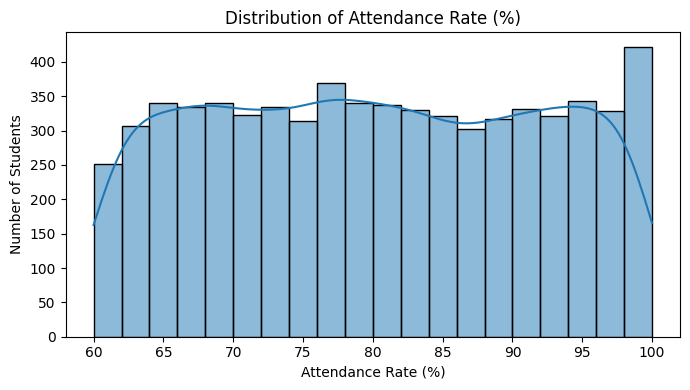

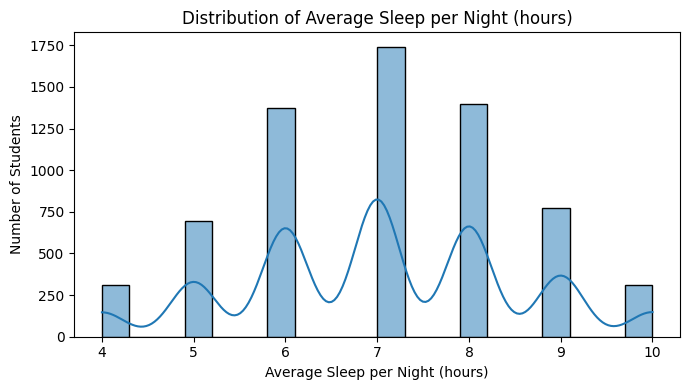

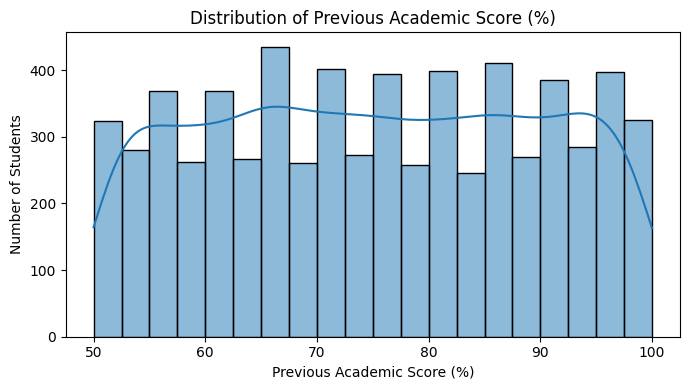

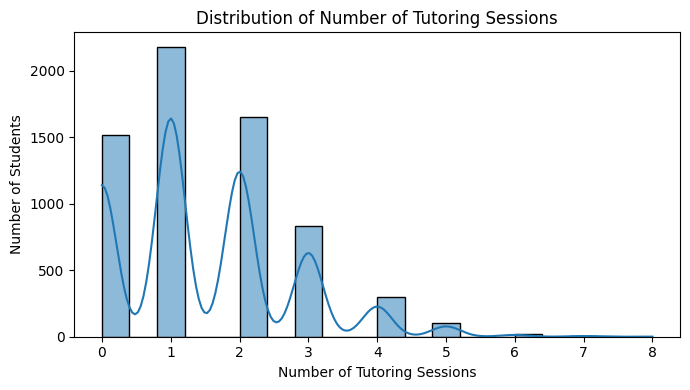

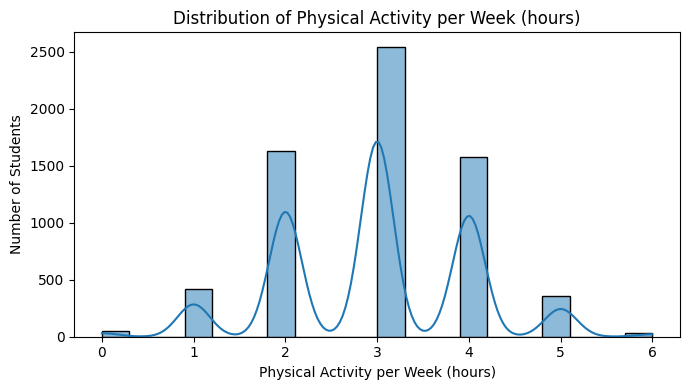

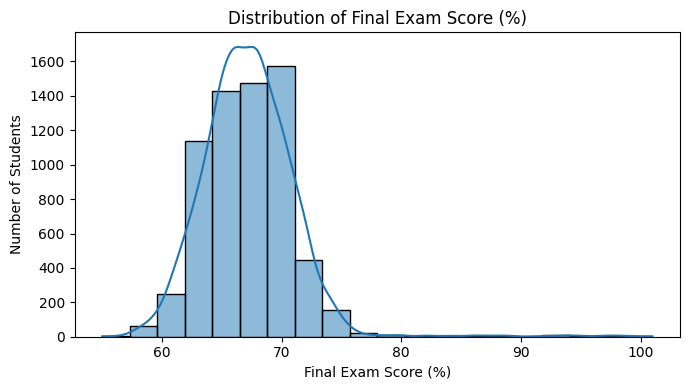

In [10]:
label_map = {
    "Hours_Studied": "Study Hours per Week (hours)",
    "Attendance": "Attendance Rate (%)",
    "Sleep_Hours": "Average Sleep per Night (hours)",
    "Exam_Score": "Final Exam Score (%)",
    "Tutoring_Sessions": "Number of Tutoring Sessions",
    "Previous_Scores": "Previous Academic Score (%)",
    "Physical_Activity": "Physical Activity per Week (hours)"
}

for col in num_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], bins=20, kde=True)

    plt.title(f"Distribution of {label_map.get(col, col)}")
    plt.xlabel(label_map.get(col, col))
    plt.ylabel("Number of Students")

    plt.tight_layout()
    plt.show()

 Summary of Numerical Feature Distributions:

- **Hours_Studied**: The distribution appears to be relatively uniform, suggesting students study a varied number of hours.
- **Attendance**: The attendance rate is generally high, with a concentration towards the higher percentages.
- **Sleep_Hours**: Most students report getting 6-8 hours of sleep, indicating a healthy sleep pattern for the majority.
- **Previous_Scores**: There's a wide range of previous scores, with a tendency for scores to be higher, possibly indicating a generally well-performing student population.
- **Tutoring_Sessions**: The majority of students have a low number of tutoring sessions, with fewer students utilizing more sessions.
- **Physical_Activity**: Physical activity hours show a spread, with some peaks at certain hour marks, suggesting common activity levels.
- **Exam_Score**: The exam scores are broadly distributed, with a central tendency around the mean (approximately 67), indicating a normal distribution of performance.

Count plots for categorical variables

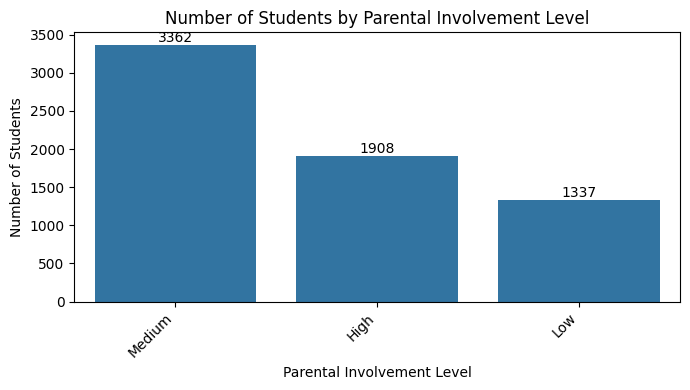

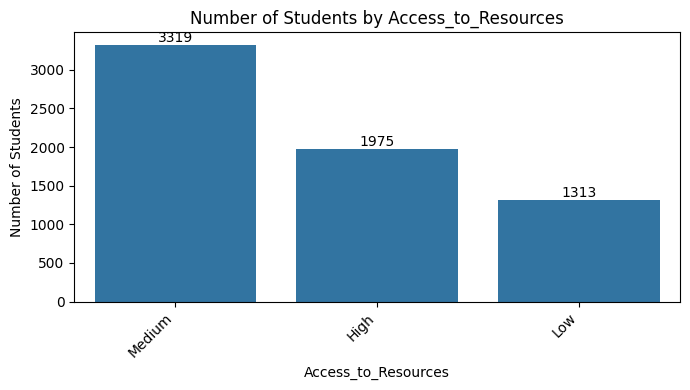

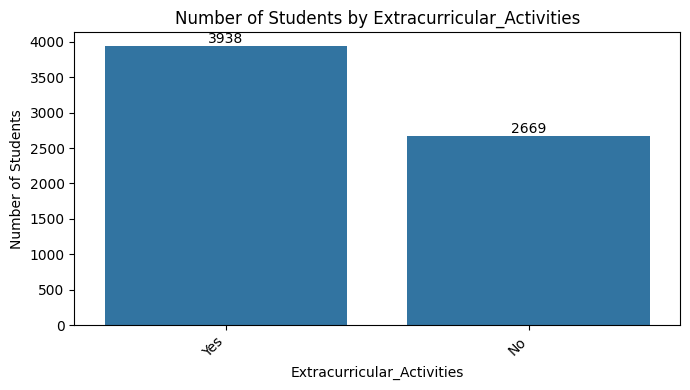

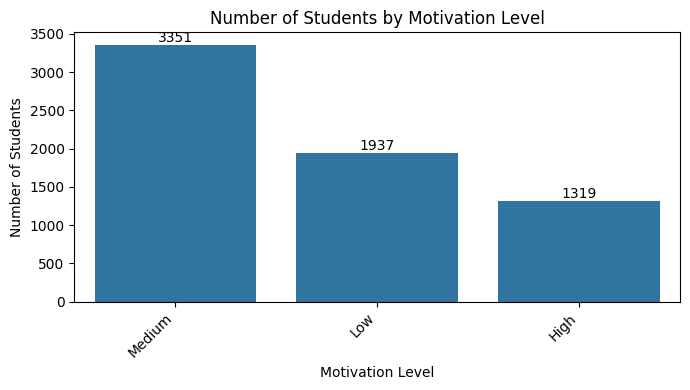

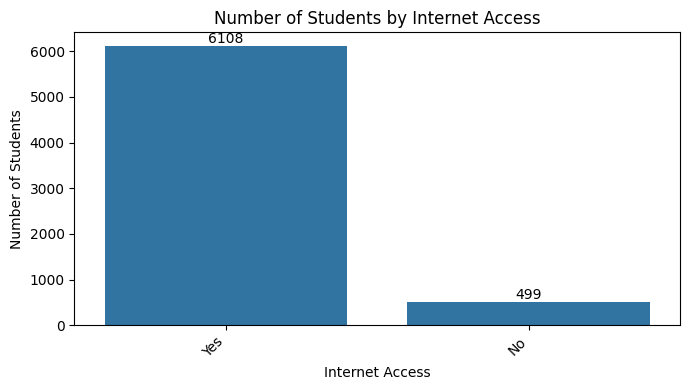

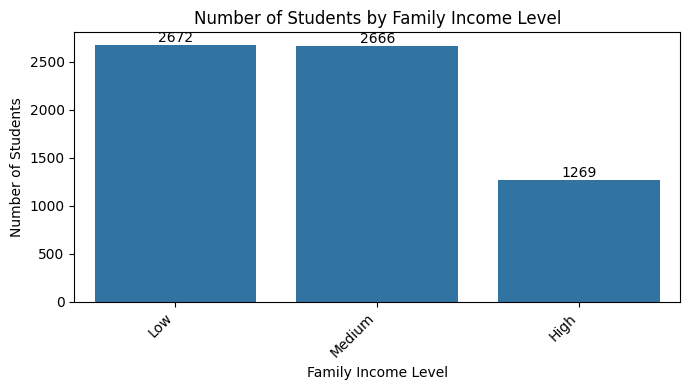

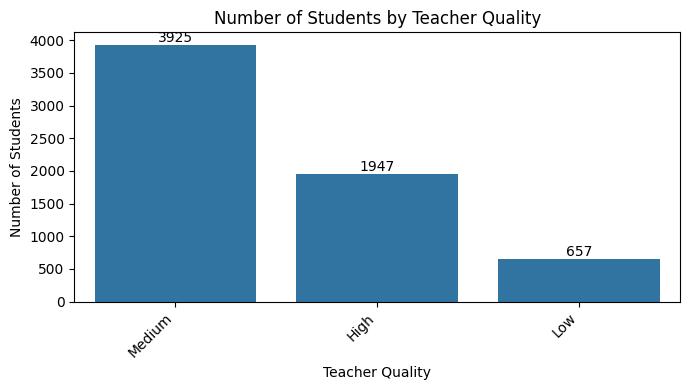

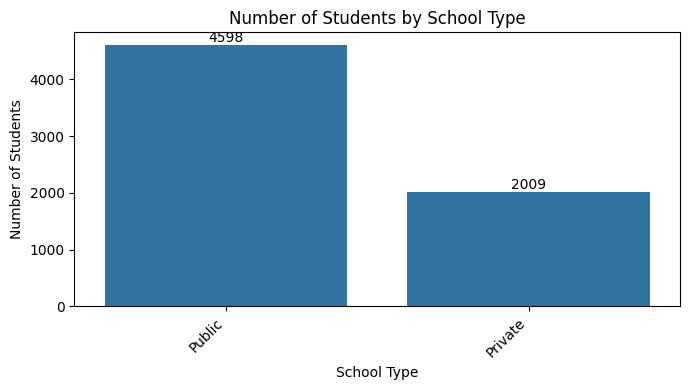

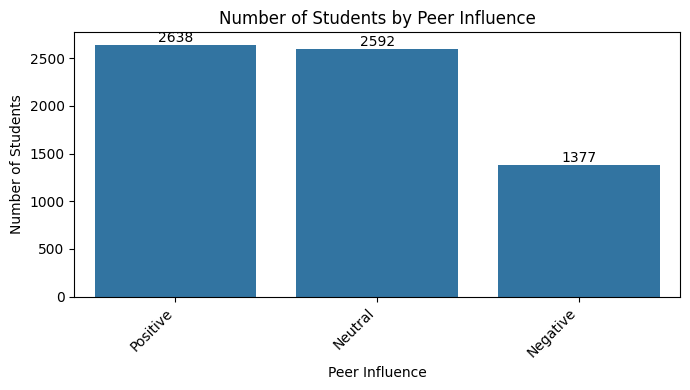

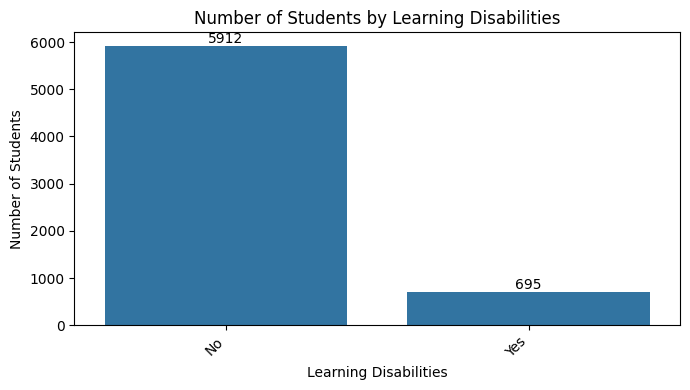

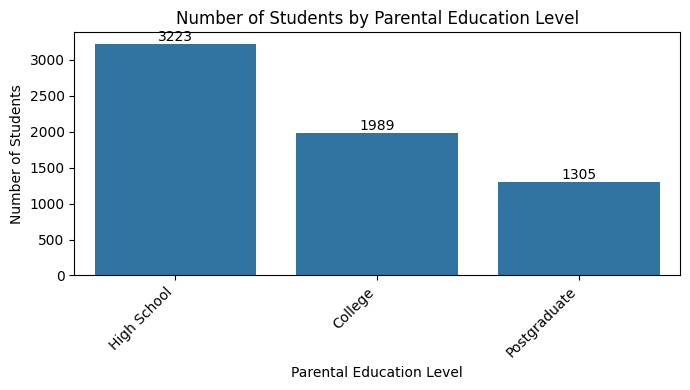

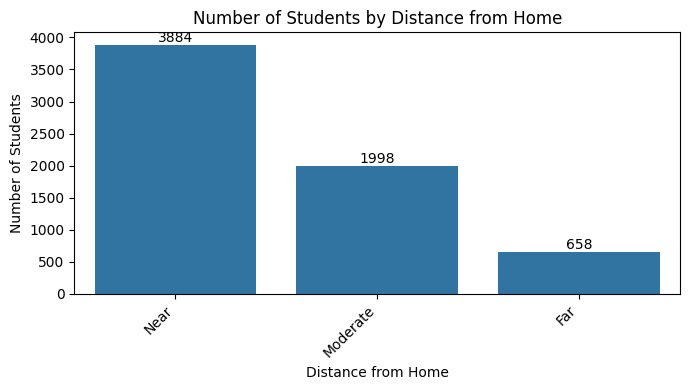

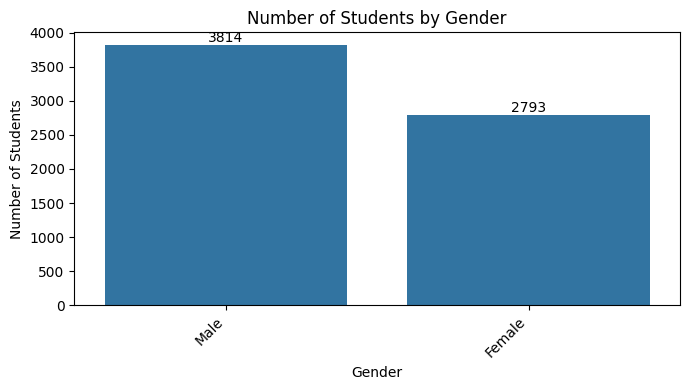

In [11]:
cat_label_map = {
    "Motivation_Level": "Motivation Level",
    "Parental_Involvement": "Parental Involvement Level",
    "School_Type": "School Type",
    "Internet_Access": "Internet Access",
    "Family_Income": "Family Income Level",
    "Teacher_Quality": "Teacher Quality",
    "Peer_Influence": "Peer Influence",
    "Learning_Disabilities": "Learning Disabilities",
    "Parental_Education_Level": "Parental Education Level",
    "Distance_from_Home": "Distance from Home",
    "Gender": "Gender"
}

for col in cat_cols:
    plt.figure(figsize=(7, 4))
    ax = sns.countplot(data=df, x=col, order=df[col].value_counts().index)

    plt.title(f"Number of Students by {cat_label_map.get(col, col)}")
    plt.xlabel(cat_label_map.get(col, col))
    plt.ylabel("Number of Students")
    plt.xticks(rotation=45, ha="right")

    for p in ax.patches:
        ax.annotate(f"{int(p.get_height())}",
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom")

    plt.tight_layout()
    plt.show()

These count plots show how students are distributed across the categorical variables in the dataset. They help identify class balance and dominant categories.

Correlation heatmap

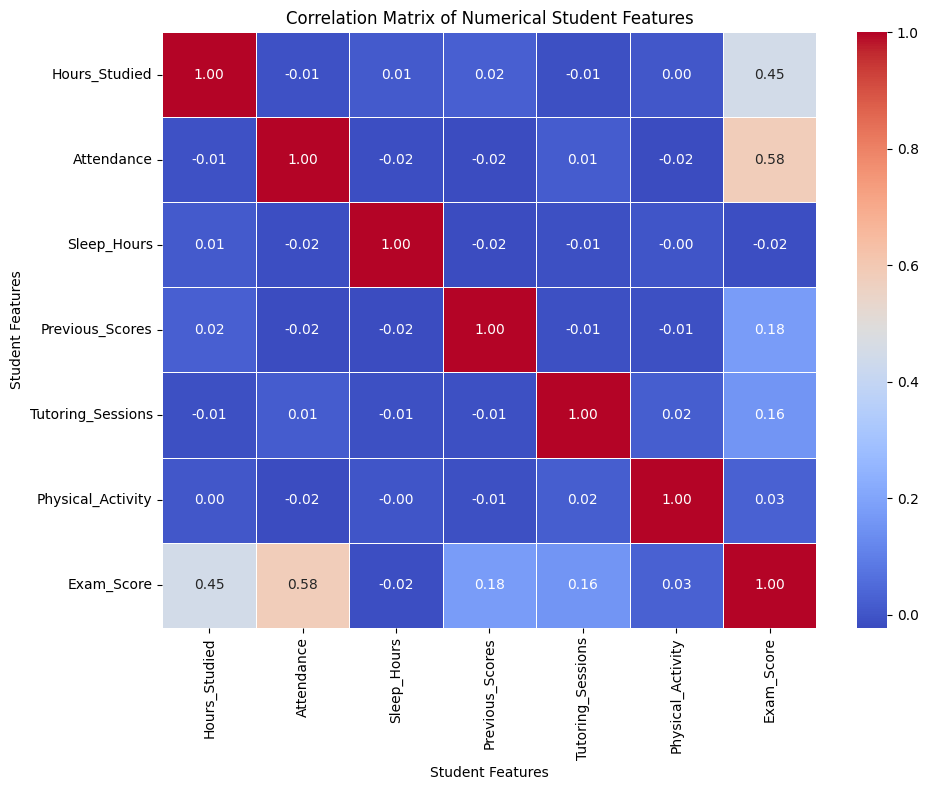

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df[num_cols].corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Student Features")
plt.xlabel("Student Features")
plt.ylabel("Student Features")

plt.tight_layout()
plt.show()

## Correlation Analysis of Numerical Features

The correlation heatmap illustrates the relationships between numerical student features and the final exam score.

### Key Observations

- **Attendance** shows the strongest positive correlation with `Exam_Score` (**0.58**), suggesting that students who attend more frequently tend to achieve higher exam scores.

- **Hours Studied** also has a moderate positive correlation with `Exam_Score` (**0.45**), indicating that increased study time is associated with better performance.

- **Previous Scores** have a weak positive relationship (**0.18**), meaning past academic performance has some influence, but not as strong as attendance or study hours.

- **Tutoring Sessions** show a small positive correlation (**0.16**), suggesting a slight benefit from tutoring.

- **Sleep Hours** and **Physical Activity** have near-zero correlation with exam score, indicating little to no linear relationship with performance in this dataset.

### Feature Relationships

- Most independent variables have very weak correlations with each other (values close to 0), indicating **low multicollinearity**.
- This suggests that each feature contributes independently rather than overlapping strongly with others.

### Conclusion

Overall, **attendance and study time appear to be the most influential factors** associated with exam performance, while lifestyle variables like sleep and physical activity show minimal direct linear impact in this dataset.

Boxplots of exam score by categorical variables

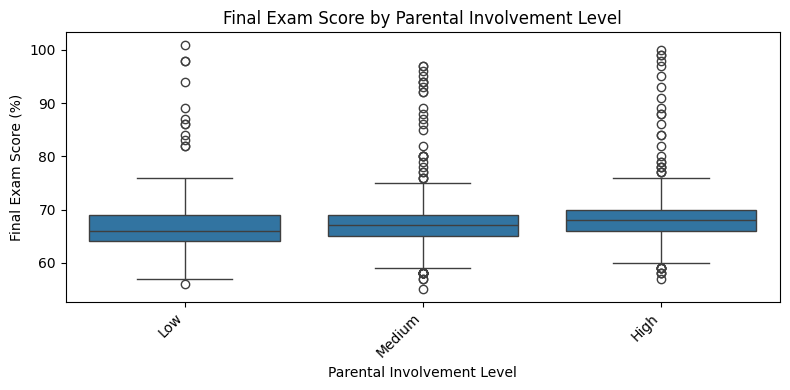

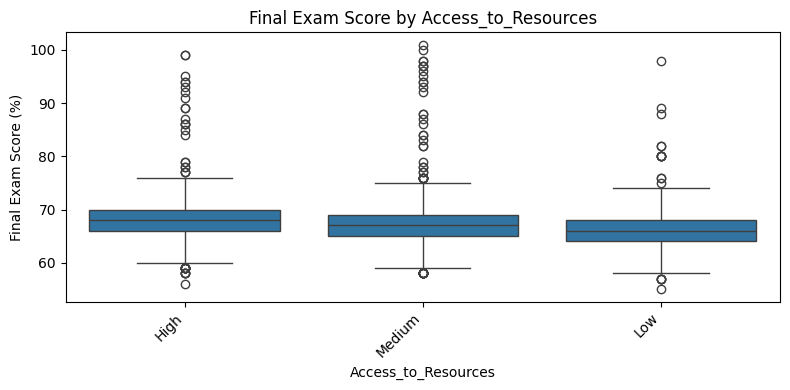

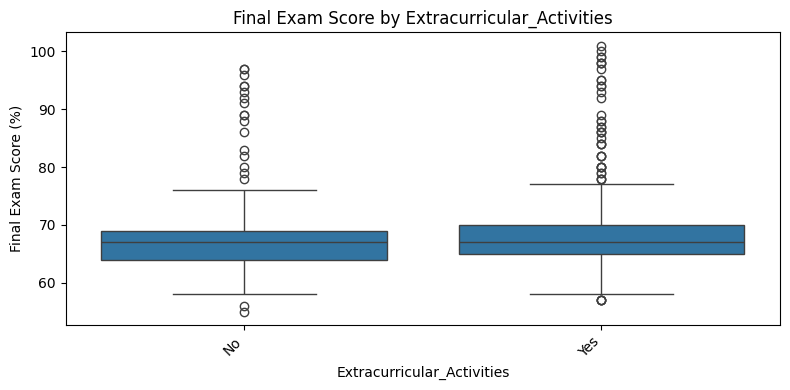

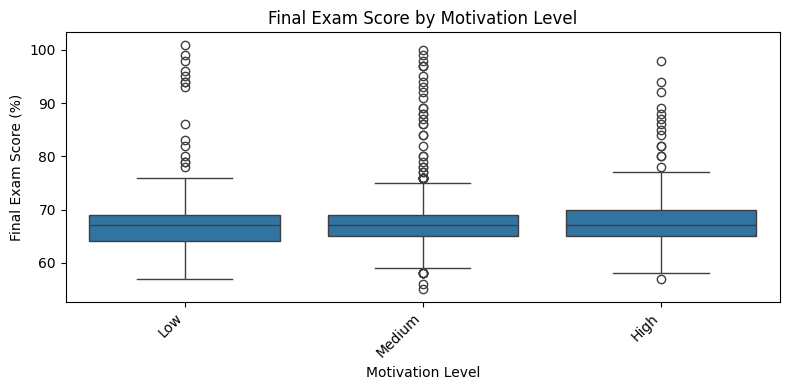

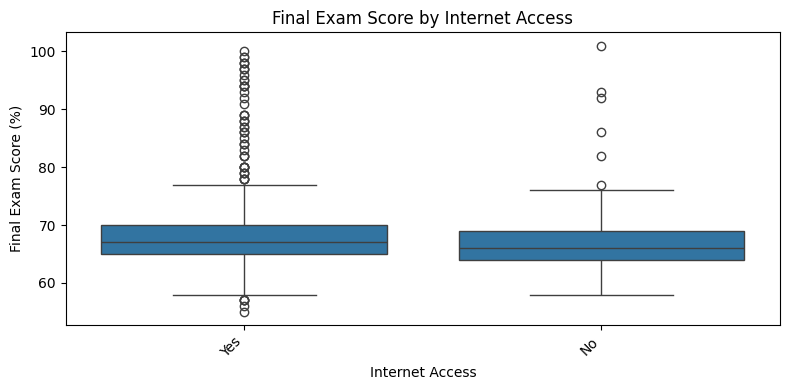

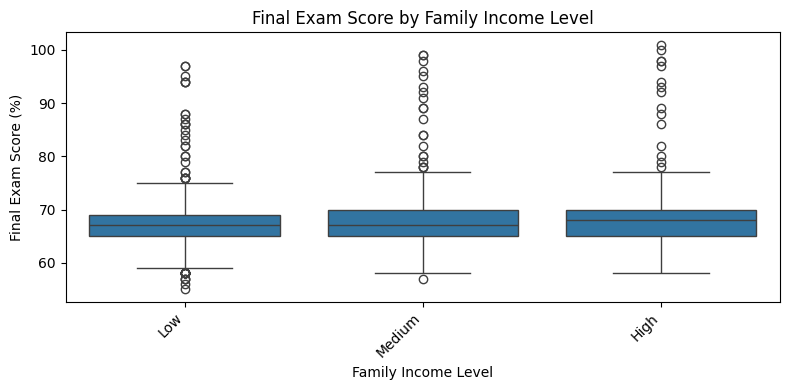

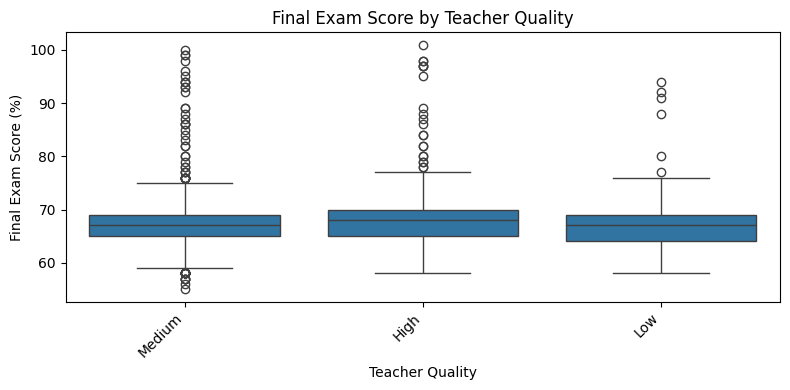

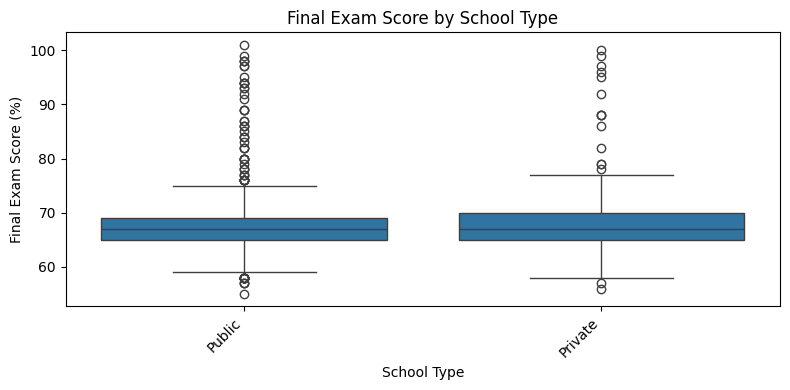

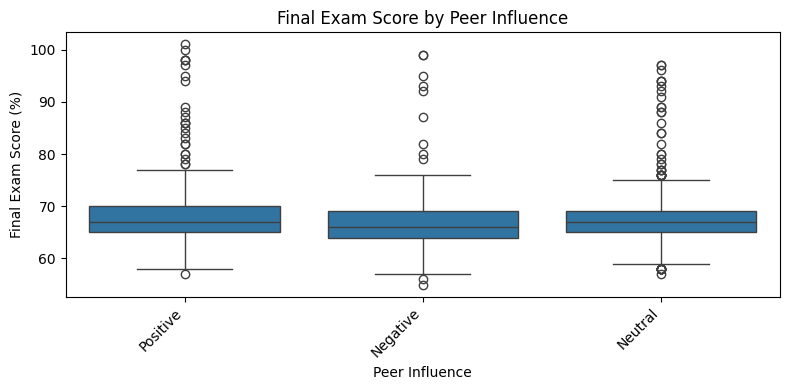

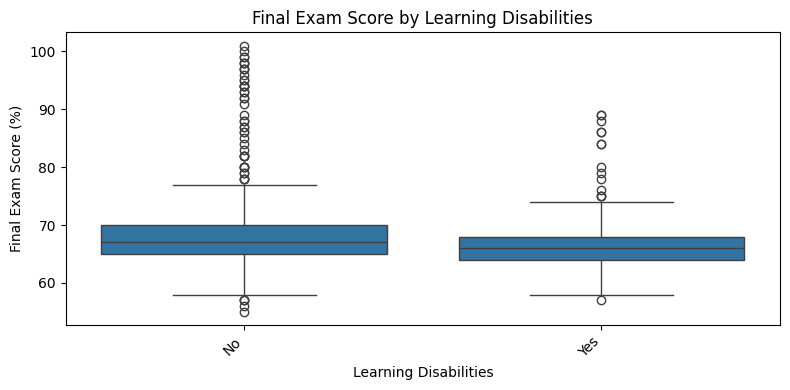

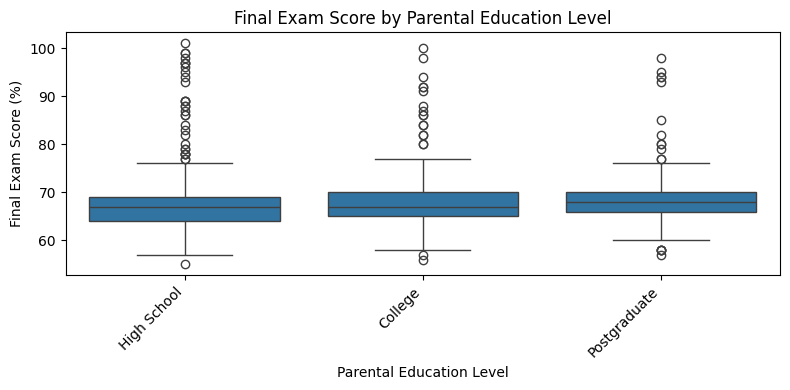

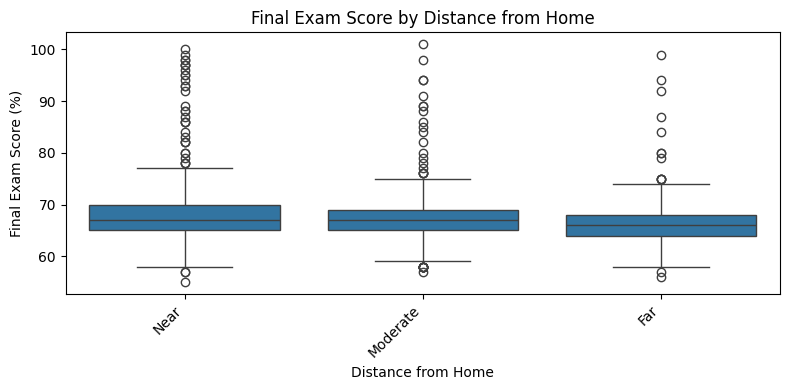

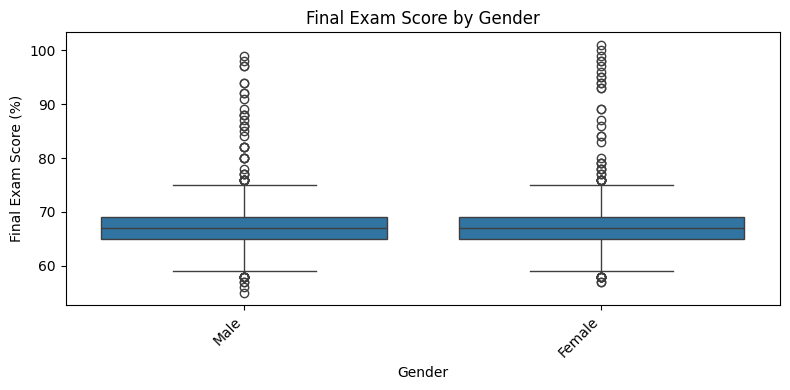

In [13]:
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=col, y="Exam_Score")

    plt.title(f"Final Exam Score by {cat_label_map.get(col, col)}")
    plt.xlabel(cat_label_map.get(col, col))
    plt.ylabel("Final Exam Score (%)")
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

These boxplots compare exam score distributions across student groups and help reveal differences in medians, spread, and possible outliers.

# Hypothesis Testing

Based on the exploratory data analysis, several potential relationships were observed between student features and exam performance.  
In this section, statistical tests are used to verify whether these relationships are statistically significant.

## Hypothesis 1: Study Hours and Exam Score

**Null Hypothesis (H0):** There is no linear relationship between study hours and exam score.

**Alternative Hypothesis (H1):** There is a positive relationship between study hours and exam score.

In [14]:
from scipy.stats import pearsonr

r, p = pearsonr(df["Hours_Studied"], df["Exam_Score"])

print("Correlation:", r)
print("p-value:", p)

Correlation: 0.44545495407528213
p-value: 1.28635e-319


## Hypothesis 2: Attendance and Exam Score

**Null Hypothesis (H0):** Attendance has no relationship with exam score.

**Alternative Hypothesis (H1):** Higher attendance is associated with higher exam score.

In [15]:
r, p = pearsonr(df["Attendance"], df["Exam_Score"])

print("Correlation:", r)
print("p-value:", p)

Correlation: 0.5810718633120641
p-value: 0.0


## Hypothesis 3: Effect of Tutoring on Exam Score

**Null Hypothesis (H0):** There is no difference in exam scores between students with and without tutoring.

**Alternative Hypothesis (H1):** Students who receive tutoring have different exam scores than those who do not.

In [16]:
df["Tutoring_Group"] = df["Tutoring_Sessions"].apply(lambda x: "With Tutoring" if x > 0 else "No Tutoring")

group1 = df[df["Tutoring_Group"] == "With Tutoring"]["Exam_Score"]
group2 = df[df["Tutoring_Group"] == "No Tutoring"]["Exam_Score"]

from scipy.stats import ttest_ind

t_stat, p = ttest_ind(group1, group2, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p)

t-statistic: 8.52146394081205
p-value: 2.6972871728554855e-17


## Hypothesis 4: Motivation Level and Exam Score

**Null Hypothesis (H0):** All motivation levels have the same mean exam score.

**Alternative Hypothesis (H1):** At least one motivation level has a different mean exam score.

In [17]:
from scipy.stats import f_oneway

groups = [grp["Exam_Score"].values for name, grp in df.groupby("Motivation_Level")]

f_stat, p = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p)

F-statistic: 25.716769950376104
p-value: 7.492319380241663e-12


## Hypothesis 5: Parental Involvement and Exam Score

**Null Hypothesis (H0):** Parental involvement has no effect on exam score.

**Alternative Hypothesis (H1):** Exam scores differ based on parental involvement level.

In [18]:
groups = [grp["Exam_Score"].values for name, grp in df.groupby("Parental_Involvement")]

f_stat, p = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p)

F-statistic: 84.48765484606247
p-value: 5.875479153325444e-37


## Interpretation of Results

- A p-value less than 0.05 indicates a statistically significant relationship.
- A p-value greater than 0.05 suggests that the observed relationship may be due to chance.

These results help confirm whether the patterns observed during exploratory data analysis are meaningful.